In [72]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1
!export BART_CPU_ONLY=1
!export CUDA_LAUNCH_BLOCKING=1

import sys
import os

os.environ['BART_TOOLBOX_PATH'] = '/home/rinbha/Packages/bart-0.9.00'
os.environ['BART_CPU_ONLY'] = '1'
sys.path.append(os.path.join(os.environ['BART_TOOLBOX_PATH'], 'python'))

import matplotlib.pyplot as plt
import numpy as np
import glob
import sigpy as sp
import sigpy.plot as pl
from scipy.interpolate import interp1d

sys.path.insert(0, "/home/rinbha/Research/BPT/BPT_MOTUS/nonrigid-motion-bpt/")

from bpt_motus.io import RadialArchive
from bpt_motus.preprocessing import SplitXkBPT
from bpt_motus.preprocessing import ProcessBPT

plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


In [60]:
def plot_bpts(bpts, tr=1, shift=None, figsize=(10,10), titles=None):
    """
    Plot BPT/PTs across all coils. Automatically shifts coil signals for visibility.
    """
    # Handle 2D input (npe, ncoils) vs 3D (nbpts, npe, ncoils)
    if bpts.ndim == 2:
        bpts = bpts[np.newaxis, ...]
        
    nbpts, npe, ncoils = bpts.shape
    
    # Auto-generate titles if not provided
    if titles is None:
        titles = [f"B+PT {i+1} PCs, Cutoff=5Hz" for i in range(nbpts)]
    
    # Demean signals for plotting
    bpt_dm = bpts - np.mean(bpts, axis=1, keepdims=True)
    
    # Automate shift: 0.5 * max magnitude across all data
    if shift is None:
        start_idx = int(0.1 * npe)  # Skip first 10% to avoid transients
        shift = 0.5 * np.max(np.abs(bpt_dm[:,start_idx:]))
        
    # Calculate grid size for subplots
    ncols = 2 if nbpts > 1 else 1
    nrows = int(np.ceil(nbpts / ncols))
    
    plt.figure(figsize=figsize)
    t = np.arange(npe) * tr
    
    # Plot
    for i in range(nbpts):
        plt.subplot(nrows, ncols, i+1)
        # Normalize by shift and offset by 1 per coil
        plt.plot(t, (bpt_dm[i] / shift) + np.arange(ncoils));
        plt.title(titles[i])
        # X-label only on the bottom row
        if i >= (nrows - 1) * ncols:
            plt.xlabel("Time (s)")

In [68]:
# Path to Radial ScanArchive folder
k = '5_demod'
inpdir = f"/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/volunteer_ute_bpt_042826/Exam54512/Series{k}"
print(f"Processing Series {k} at {inpdir}")

# # Get k-space and metadata
# radial = RadialArchive(inpdir)
# # radial.get_metadata(force_reload=True)
# radial.get_ksp(force_reload=True)

# # Get BPT and BPT-free k-space
# split_xk_bpt = SplitXkBPT(inp_dir=inpdir, verbose=True)
# split_xk_bpt.num_bpts = 1
# split_xk_bpt.run(force_reload=True)

# Get processed BPT signals
process_bpt = ProcessBPT(inp_dir=inpdir, phase="calib", verbose=True, nrank=6)
process_bpt.lpf_cutoff_hz = 5
process_bpt.do_ssa = False
process_bpt.run(force_reload=True) # can set to false

INFO: Processed BPT/PTs not found. Extracting them...
INFO: TR found from metadata: 2.93 ms
INFO: Loading raw BPT/PTs...
INFO: Applying median filter to BPT/PTs...


Processing Series 5_demod at /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/volunteer_ute_bpt_042826/Exam54512/Series5_demod


INFO: Applying low-pass filter to BPT/PTs...
INFO: Skipping SSA...
INFO: Normalizing BPT/PTs...
INFO: Applying PCA to BPT/PTs...


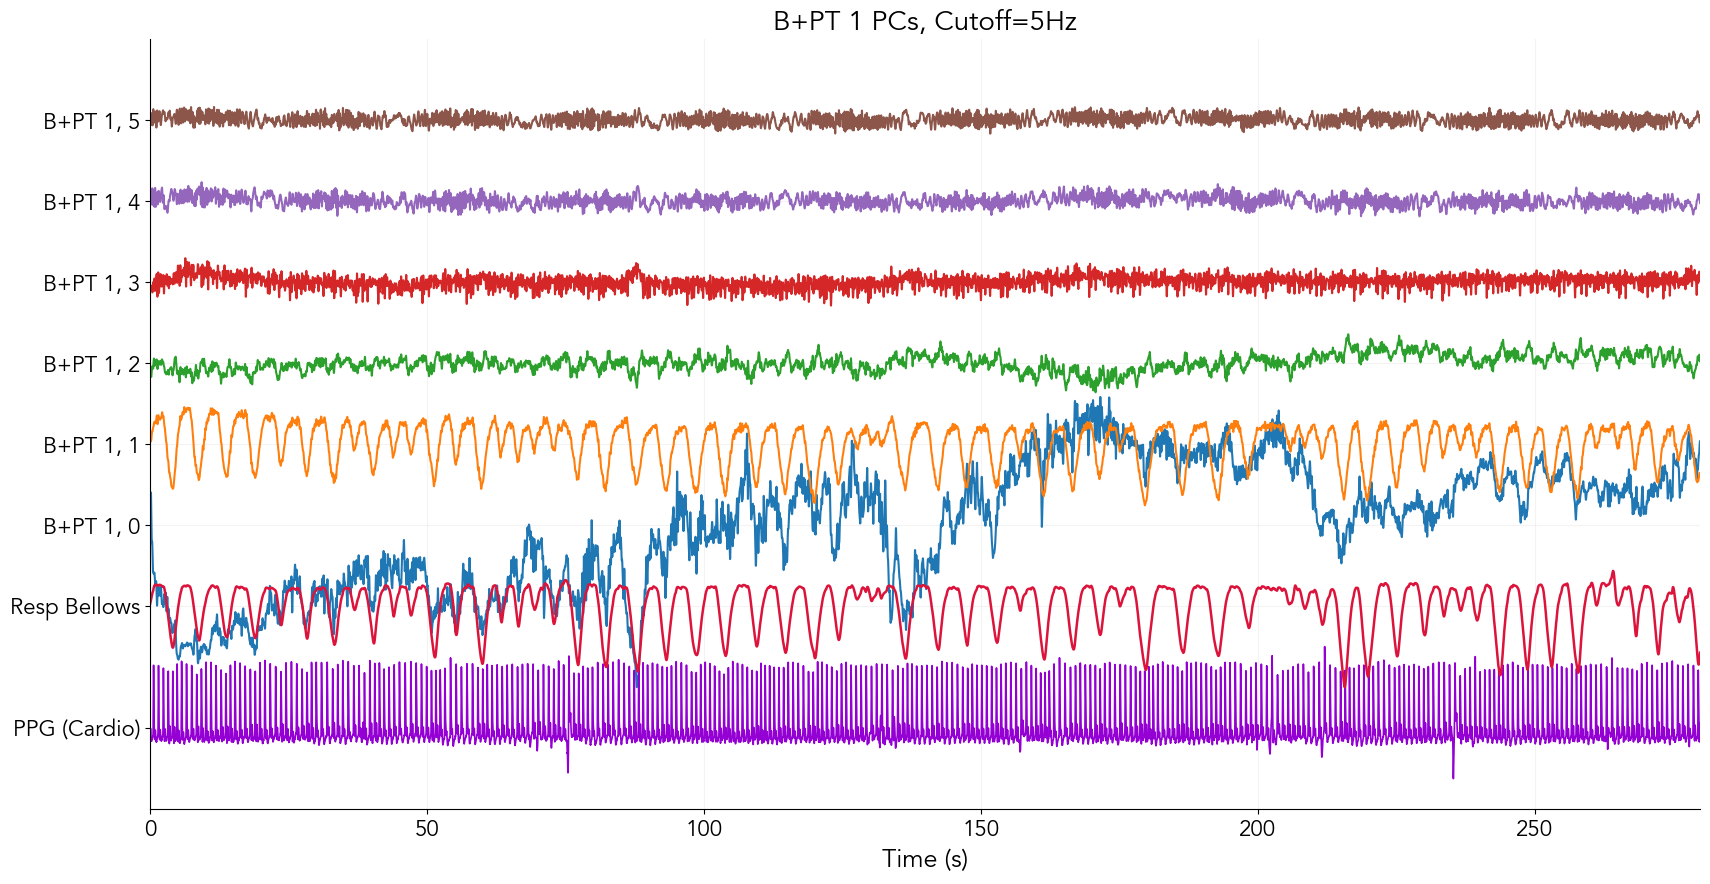

In [67]:
def plot_mri_and_physio_combined(bpts, tr, inpdir, plot_bpt=True, plot_resp=True, plot_cardio=False, 
                                 time_range=None, figsize=(10, 10)):
    """
    Leverages plot_bpts to render the layout, shifts the coils up to place physio
    signals at the bottom, and explicitly customizes the Y-axis labels.
    Dynamically aligns timelines by calculating and cutting off the pre-scan physio lead time.
    
    Parameters:
    -----------
    time_range : list or tuple, optional
        Specify a bounding box window to plot in seconds, e.g., [0, 2]. 
        Defaults to None (displays full acquisition duration).
    """
    # 1. Generate the initial figure grid layout
    if plot_bpt:
        plot_bpts(bpts, tr=tr, figsize=figsize)
    else:
        nbpts = bpts.shape[0] if bpts.ndim == 3 else 1
        ncols = 2 if nbpts > 1 else 1
        nrows = int(np.ceil(nbpts / ncols))
        plt.figure(figsize=figsize)
        for i in range(nbpts):
            plt.subplot(nrows, ncols, i + 1)
            if bpts.ndim == 3:
                plt.title(f"B+PT {i+1} PCs, Cutoff=5Hz")
            else:
                plt.title("B+PT 1 PCs, Cutoff=5Hz")
    
    ncoils = bpts.shape[-1]
    npe = bpts.shape[-2]
    max_time_sec = (npe - 1) * tr
    
    # Helper to load, dynamically crop, and independently scale a physio file
    def get_physio_trace(file_pattern, dt):
        matches = glob.glob(os.path.join(inpdir, file_pattern))
        if not matches:
            return None, None
            
        raw_data = np.loadtxt(matches[0])
        fs = 1.0 / dt
        
        total_physio_duration = len(raw_data) * dt
        if total_physio_duration > max_time_sec:
            discard_sec = 31.0
        else:
            discard_sec = 0.0
            
        start_idx = int(discard_sec * fs)
        if start_idx >= len(raw_data):
            return None, None
        cropped = raw_data[start_idx:]
        
        t_axis = np.arange(len(cropped)) * dt
        time_mask = t_axis <= max_time_sec
        t_axis = t_axis[time_mask]
        final_signal = cropped[:len(t_axis)]
        
        sig_dm = final_signal - np.mean(final_signal)
        sig_norm = sig_dm / np.max(np.abs(sig_dm))
        
        return t_axis, sig_norm

    # 2. Load the requested physiological signals up-front
    resp_data = get_physio_trace("RESPData_uwute*", dt=0.04) if plot_resp else (None, None)
    cardio_data = get_physio_trace("PPGData_uwute*", dt=0.01) if plot_cardio else (None, None)
    
    # 3. Intercept all subplots currently open on the active figure window
    fig = plt.gcf()
    axes = fig.get_axes()
    
    for ax in axes:
        subplot_title = ax.get_title()
        
        bottom_clearance = 0.0
        if plot_resp: bottom_clearance += 1.5
        if plot_cardio: bottom_clearance += 1.5
        
        original_lines = list(ax.get_lines())
        
        if plot_bpt:
            for line in original_lines:
                x_val, y_val = line.get_data()
                line.set_ydata(y_val + bottom_clearance)
            
        y_ticks = []
        y_tick_labels = []
        current_vertical_offset = 0.5
        
        # Plot Cardio (PPG)
        t_ppg, ppg_norm = cardio_data
        if ppg_norm is not None:
            ax.plot(t_ppg, ppg_norm + current_vertical_offset, color='darkviolet', linewidth=1.2)
            y_ticks.append(current_vertical_offset)
            y_tick_labels.append("PPG (Cardio)")
            current_vertical_offset += 1.5
            
        # Plot Respiration
        t_resp, resp_norm = resp_data
        if resp_norm is not None:
            ax.plot(t_resp, resp_norm + current_vertical_offset, color='crimson', linewidth=1.8)
            y_ticks.append(current_vertical_offset)
            y_tick_labels.append("Resp Bellows")
            current_vertical_offset += 1.5

        if plot_bpt:
            for k in range(ncoils):
                coil_center_y = k + bottom_clearance
                y_ticks.append(coil_center_y)
                if subplot_title:
                    prefix = subplot_title.split('PCs', 1)[0].strip()
                    y_tick_labels.append(f"{prefix}, {k}")
                else:
                    y_tick_labels.append(f"PC {k}")
            y_max_limit = ncoils + bottom_clearance
        else:
            y_max_limit = current_vertical_offset

        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_tick_labels)
        ax.set_ylabel("") 
        ax.set_xlabel("Time (s)")
        
        # --- Dynamic Viewport Limit Routing ---
        if time_range is not None:
            ax.set_xlim(time_range[0], time_range[1])
        else:
            ax.set_xlim(0, max_time_sec)
            
        ax.set_ylim(-0.5, y_max_limit)
        ax.grid(True, alpha=0.15)
        
    plt.draw()
    plt.show()

time_range = None # [0,10]
plot_cardio = True
plot_resp = True
plot_bpt = True
plot_mri_and_physio_combined(
    process_bpt.bpts_proc, process_bpt.tr, inpdir, 
    plot_bpt=plot_bpt, plot_resp=plot_resp, plot_cardio=plot_cardio, 
    time_range=time_range, figsize=(20, 10)
)

### Demodulate k-space debugging (unresolved; used pcvipr flag instead)

In [69]:
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/volunteer_ute_bpt_042826/Exam54512/Series2"

radial = RadialArchive(inp_dir=inpdir)
radial.get_ksp(force_reload=False)

INFO: Loading cached raw radial data from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/volunteer_ute_bpt_042826/Exam54512/Series2...


In [70]:
radial.xk_time.shape

(31, 99900, 618)

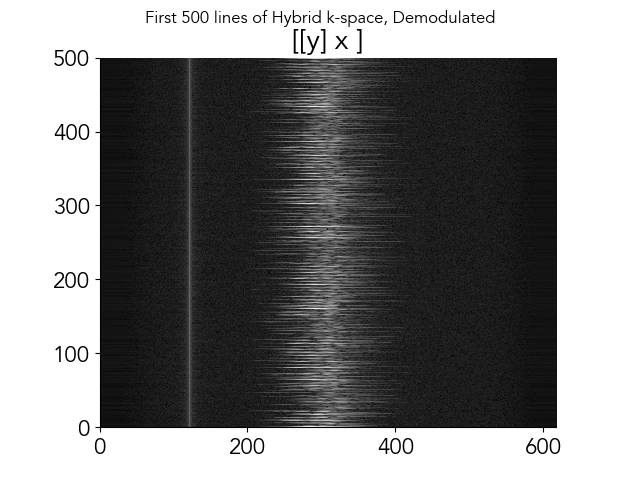

In [74]:
pl.ImagePlot(np.abs(sp.ifft(radial.xk_time[0,:500,:],axes=(-1,)))**(1/3), title="First 500 lines of Hybrid k-space, Demodulated")

In [15]:
def verify_class_demodulation(obj, spoke_indices=[100, 300, 5000], pad_factor=10):
    """
    Diagnostic verification script.
    Pulls data directly from the class state after demodulation to verify
    that the peaks have snapped cleanly onto the baseline target.
    """
    coil_id = 0
    nr = obj.xk_ordered.shape[-1]
    
    # 1. Setup search regions for the Pilot Tone peaks
    center_start = int(nr * obj.edge_frac)
    center_end = nr - center_start
    indices = np.concatenate([np.arange(center_start), np.arange(center_end, nr)])
    
    # Compute the global baseline target profile from uncorrected data
    xk_f_raw_all = sp.ifft(obj.xk_ordered[coil_id], axes=(-1,))
    rss_profile = np.sqrt(np.mean(np.abs(xk_f_raw_all)**2, axis=0))
    
    def get_fine_peak_precision(f_signal):
        """Finds the sub-voxel peak index using a local cubic spline."""
        sig_masked = np.abs(f_signal).copy()
        sig_masked[center_start:center_end] = 0.0
        
        coarse_peak = np.argmax(sig_masked)
        window_size = 3
        x_coarse = np.arange(coarse_peak - window_size, coarse_peak + window_size + 1)
        y_coarse = sig_masked[x_coarse]
        
        x_fine = np.linspace(x_coarse[0], x_coarse[-1], len(x_coarse) * pad_factor)
        f_interp = interp1d(x_coarse, y_coarse, kind='cubic')
        y_fine = f_interp(x_fine)
        
        return x_fine[np.argmax(y_fine)]

    # Locate the high-precision target peak position
    target_peak_fine = get_fine_peak_precision(rss_profile)
    
    # Grab the calculated offsets directly from the class to display in the titles
    class_offsets = obj._get_demod_offsets()
    
    # 2. Plotting loop
    fig, axes = plt.subplots(len(spoke_indices), 1, figsize=(12, 3.5 * len(spoke_indices)), sharex=True)
    if len(spoke_indices) == 1: 
        axes = [axes]
        
    for idx, s_id in enumerate(spoke_indices):
        ax = axes[idx]
        
        # Pull original and corrected profiles directly from the class data arrays
        raw_f = sp.ifft(obj.xk_ordered[coil_id, s_id])
        corrected_f = sp.ifft(obj.xk_demod[coil_id, s_id]) # Class output array
        
        # Calculate precision sub-voxel distances relative to target baseline
        raw_distance = get_fine_peak_precision(raw_f) - target_peak_fine
        corrected_distance = get_fine_peak_precision(corrected_f) - target_peak_fine
        
        # Render the curves
        ax.plot(indices, rss_profile[indices], label='Global Baseline (Target)', 
                color='gray', linestyle='--', alpha=0.5, linewidth=2)
        ax.plot(indices, np.abs(raw_f[indices]), label='Raw Spoke (Uncorrected)', 
                color='crimson', alpha=0.4, linestyle=':')
        ax.plot(indices, np.abs(corrected_f[indices]), label='Class Corrected Spoke', 
                color='teal', alpha=0.9, linewidth=2)
        
        title_text = (
            f"Spoke {s_id:4d} | Class Computed Shift: {class_offsets[s_id]:+.2f} bins\n"
            f"Original Distance to Target: {raw_distance:+.2f} bins | "
            f"Corrected Distance to Target: {corrected_distance:+.2f} bins"
        )
        ax.set_title(title_text, fontsize=11)
        ax.set_ylabel("Magnitude")
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.2)
        
    plt.xlabel("Frequency Bin Index")
    plt.tight_layout()
    plt.show()

verify_class_demodulation(split_xk_bpt, spoke_indices=[100, 300, 5000])
pl.ImagePlot(np.abs(sp.ifft(split_xk_bpt.xk_ordered[0,:200],axes=(-1,))[...,:200])**(1/3))

AttributeError: 'NoneType' object has no attribute 'shape'